# Figs. 5-6 - 3D Embedded Leslie

Two parameter regimes of the same architecture:

1. **Spurious-attractor regime** (`leslie3d_spurious.yaml`, Fig. 5):
   the latent Morse graph reports an extra attractor whose lift fails
   the semiconjugacy check (`is_spurious_attractor: true`).
2. **Success regime** (`leslie3d_success.yaml`, Fig. 6): the latent
   Morse graph matches the high-dimensional structure.

Both cells load the corresponding autoencoder from disk, re-render the
Morse plots, and (for the spurious case) overlay periodic-orbit
trajectories in the latent space.

In [1]:
import os
os.environ.setdefault('MPLBACKEND', 'module://matplotlib_inline.backend_inline')
%matplotlib inline

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from IPython.display import Image, display
from latentdynamics.config import load_config
from latentdynamics.training import load_any_checkpoint
from latentdynamics.viz import render_morse_from_files

REPO_ROOT = Path.cwd().resolve().parent  # code/
RENDER_ROOT = Path.cwd() / 'rendered'
RENDER_ROOT.mkdir(exist_ok=True)

DEVICE = (
    torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cuda') if torch.cuda.is_available()
    else torch.device('cpu')
)
print('device:', DEVICE)

device: mps


In [2]:
def _seed_dir(cfg, seed):
    return REPO_ROOT / cfg.paths.output_dir / f'seed_{seed}'

def _scaler_dir(cfg, train_file='train'):
    return REPO_ROOT / cfg.paths.output_dir / 'scalers' / train_file

def _bounds_from_log(path):
    if not path.exists():
        return None, None
    lower = upper = None
    for line in path.read_text().splitlines():
        k = line.split(':', 1)[0].strip().lower()
        if k == 'lower bounds':
            lower = json.loads(line.split(':', 1)[1])
        elif k == 'upper bounds':
            upper = json.loads(line.split(':', 1)[1])
    return lower, upper

def show(path, width=600):
    display(Image(filename=str(path), width=width))

def load_replay(cfg, seed, train_file='train'):
    seed_dir = _seed_dir(cfg, seed)
    if not seed_dir.exists():
        raise FileNotFoundError(seed_dir)
    model, arch = load_any_checkpoint(seed_dir / 'models', arch=cfg.arch, map_location=DEVICE)
    model.to(DEVICE).eval()
    scaler_path = _scaler_dir(cfg, train_file) / 'scaler.gz'
    scaler = joblib.load(scaler_path) if scaler_path.exists() else None
    return seed_dir, model, arch, scaler

@torch.no_grad()
def encode_batch(model, scaler, x_high):
    x = scaler.transform(x_high) if scaler is not None else x_high
    return model.encoder(torch.as_tensor(x, dtype=torch.float32, device=DEVICE)).cpu().numpy()

@torch.no_grad()
def advance_latent(model, z_low):
    z = torch.as_tensor(z_low, dtype=torch.float32, device=DEVICE)
    return model.latent_map(z).cpu().numpy()

## Spurious regime

seed_dir: /Users/bdoprad/Work/Projects/latent-dynamics/code/output/leslie3d_spurious/seed_2 | arch: 3 -> 2


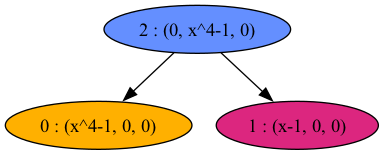

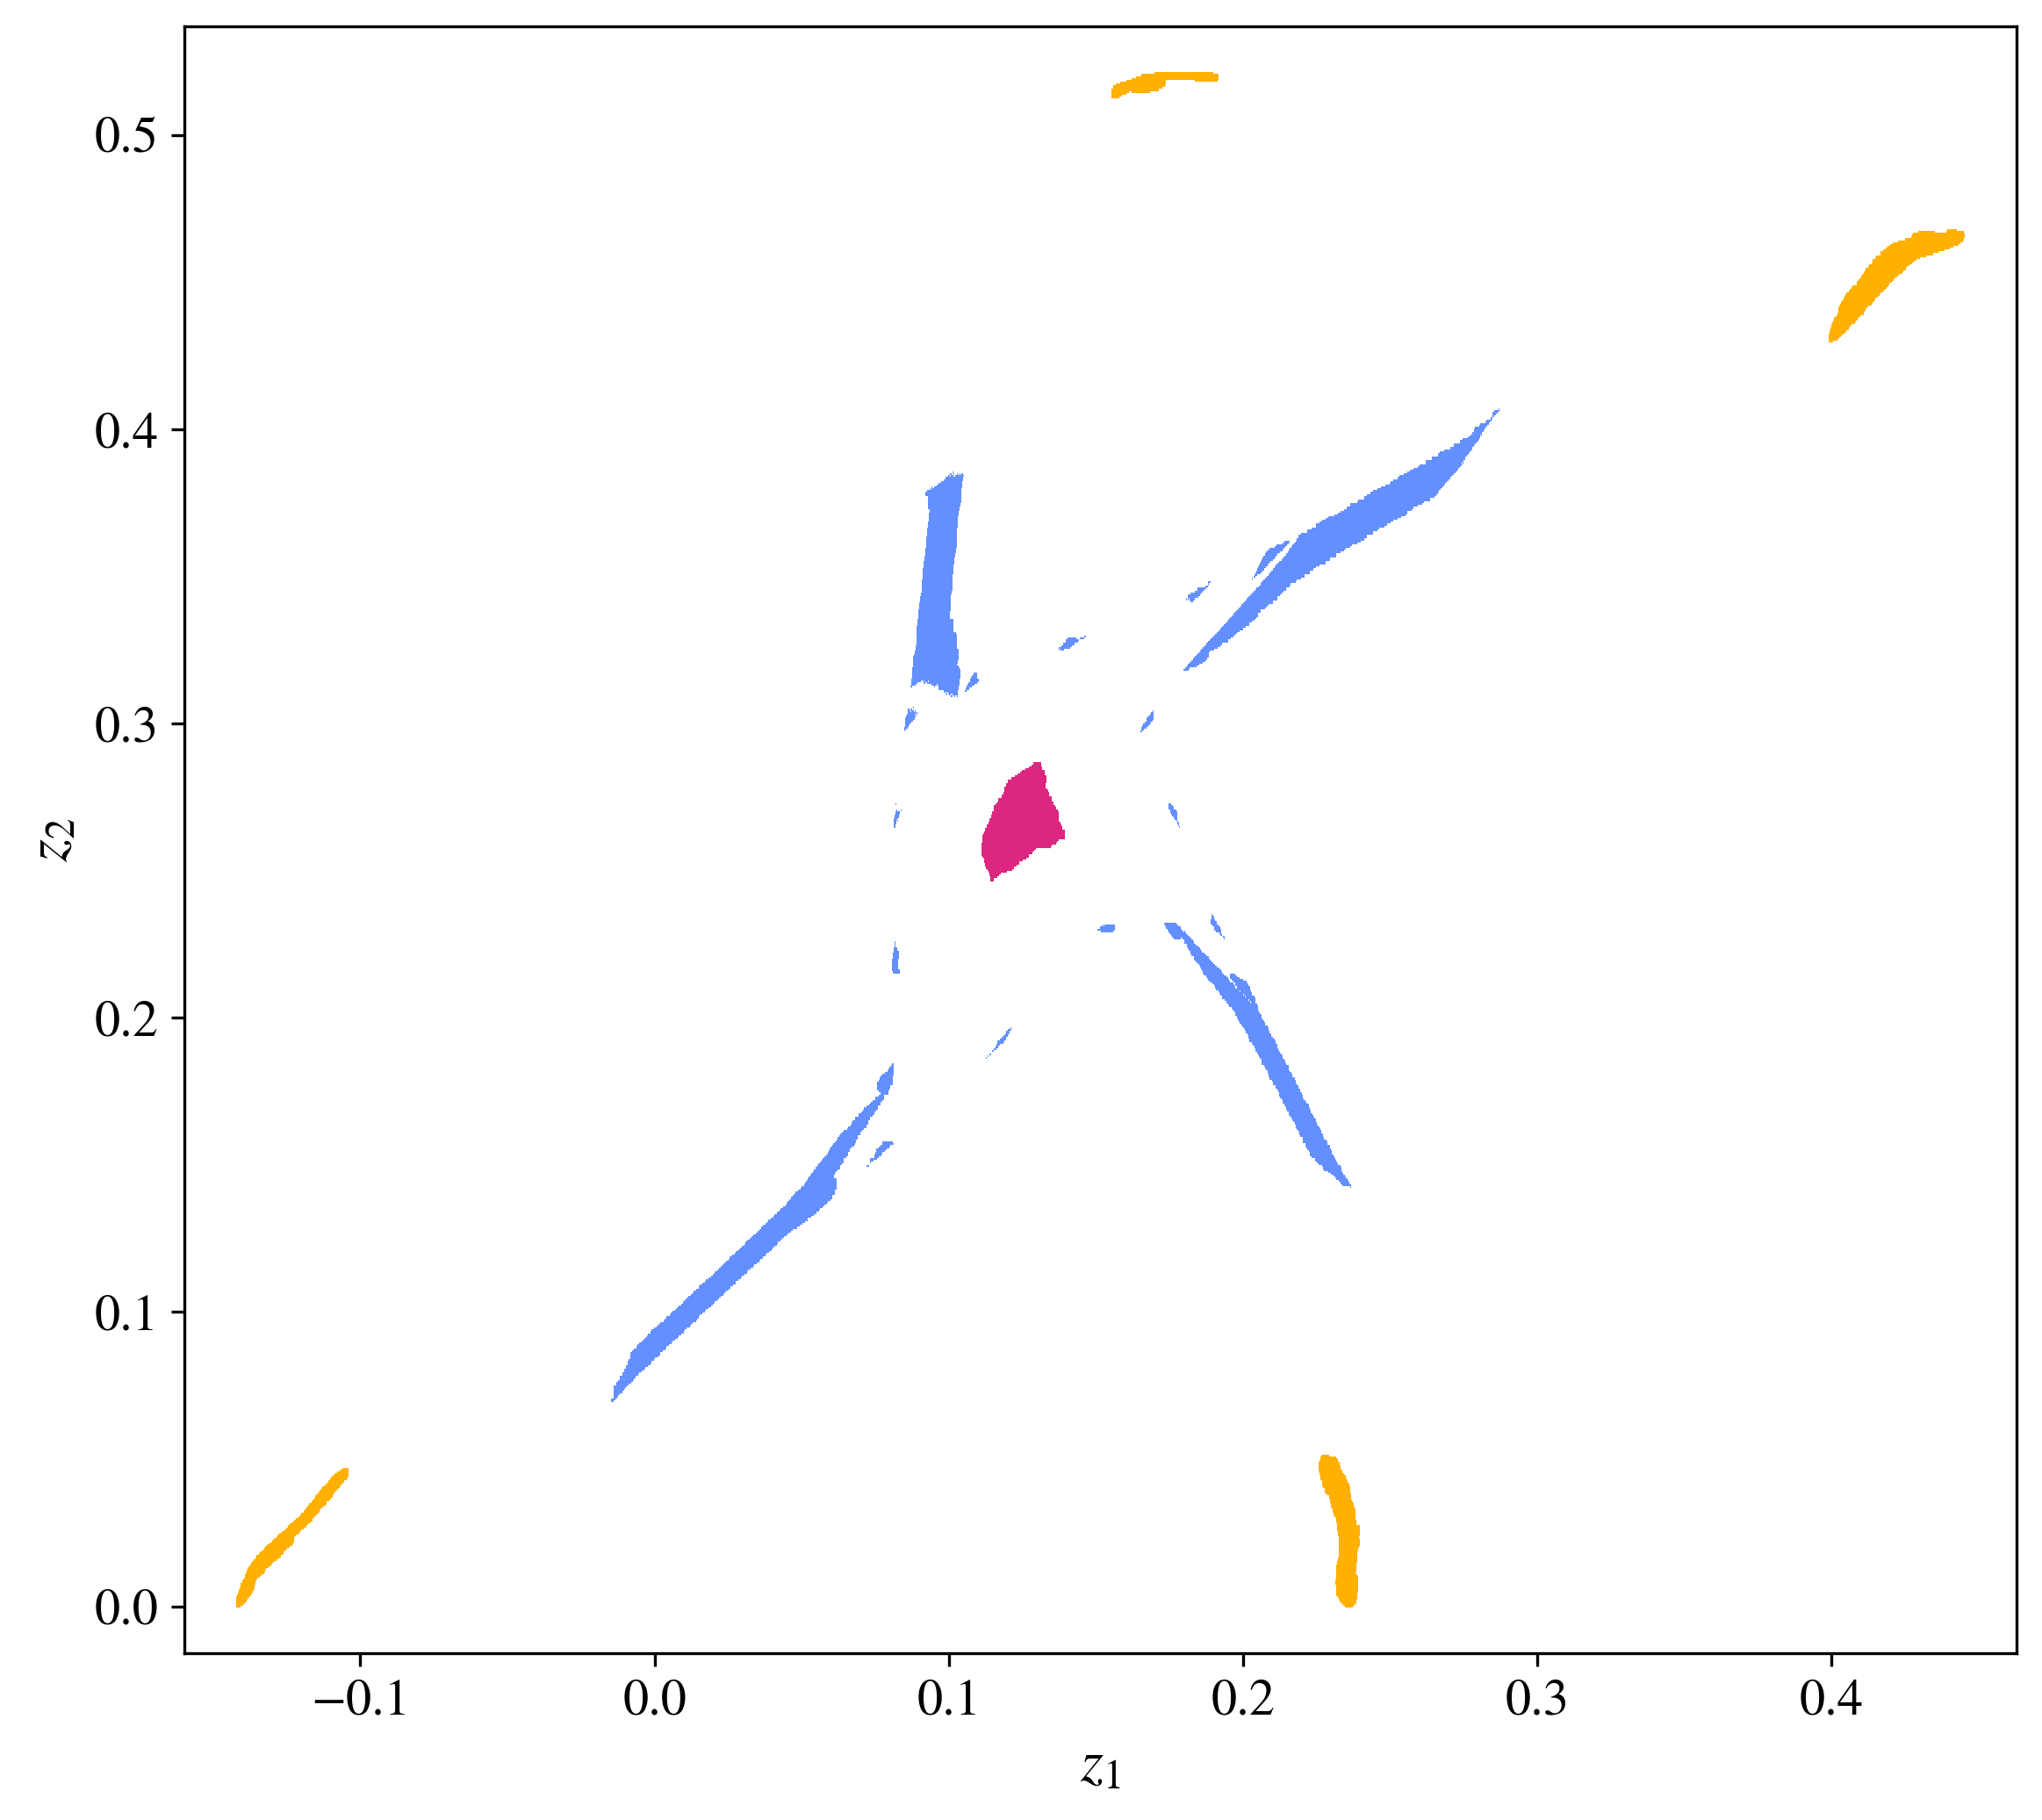

-- metrics.json --
{
  "target_label": 0,
  "tau_bar": 0.0002652853727340698,
  "max_semiconjugacy_error": 0.009517243131995201,
  "n_semiconjugacy_samples": 121,
  "is_spurious_attractor": true
}


In [3]:
cfg_sp = load_config(REPO_ROOT / 'configs' / 'leslie3d_spurious.yaml')
SEED_SP = cfg_sp.seeds[0]
seed_dir_sp, model_sp, arch_sp, scaler_sp = load_replay(cfg_sp, SEED_SP)
print('seed_dir:', seed_dir_sp, '| arch:', arch_sp.high_dims, '->', arch_sp.low_dims)

lower, upper = _bounds_from_log(seed_dir_sp / 'mg_params_log.txt')
render_dir = RENDER_ROOT / 'leslie3d_spurious'
figs = render_morse_from_files(seed_dir_sp / 'MG', bounds_lower=lower, bounds_upper=upper, out_dir=render_dir)
show(figs.morse_graph_png)
for p in figs.morse_sets_paths:
    if p.suffix == '.png':
        show(p, width=720)

print('-- metrics.json --')
print(json.dumps(json.loads((seed_dir_sp / 'metrics.json').read_text()), indent=2))

### Latent-trajectory overlay (Fig. 5)

Encode a representative point on each of the high-dimensional periodic
orbits and iterate the latent map four times. The trajectory inside the
spurious Morse set never reaches a fixed point of the ambient
dynamics - that is the failure mode the experiment is built to expose.

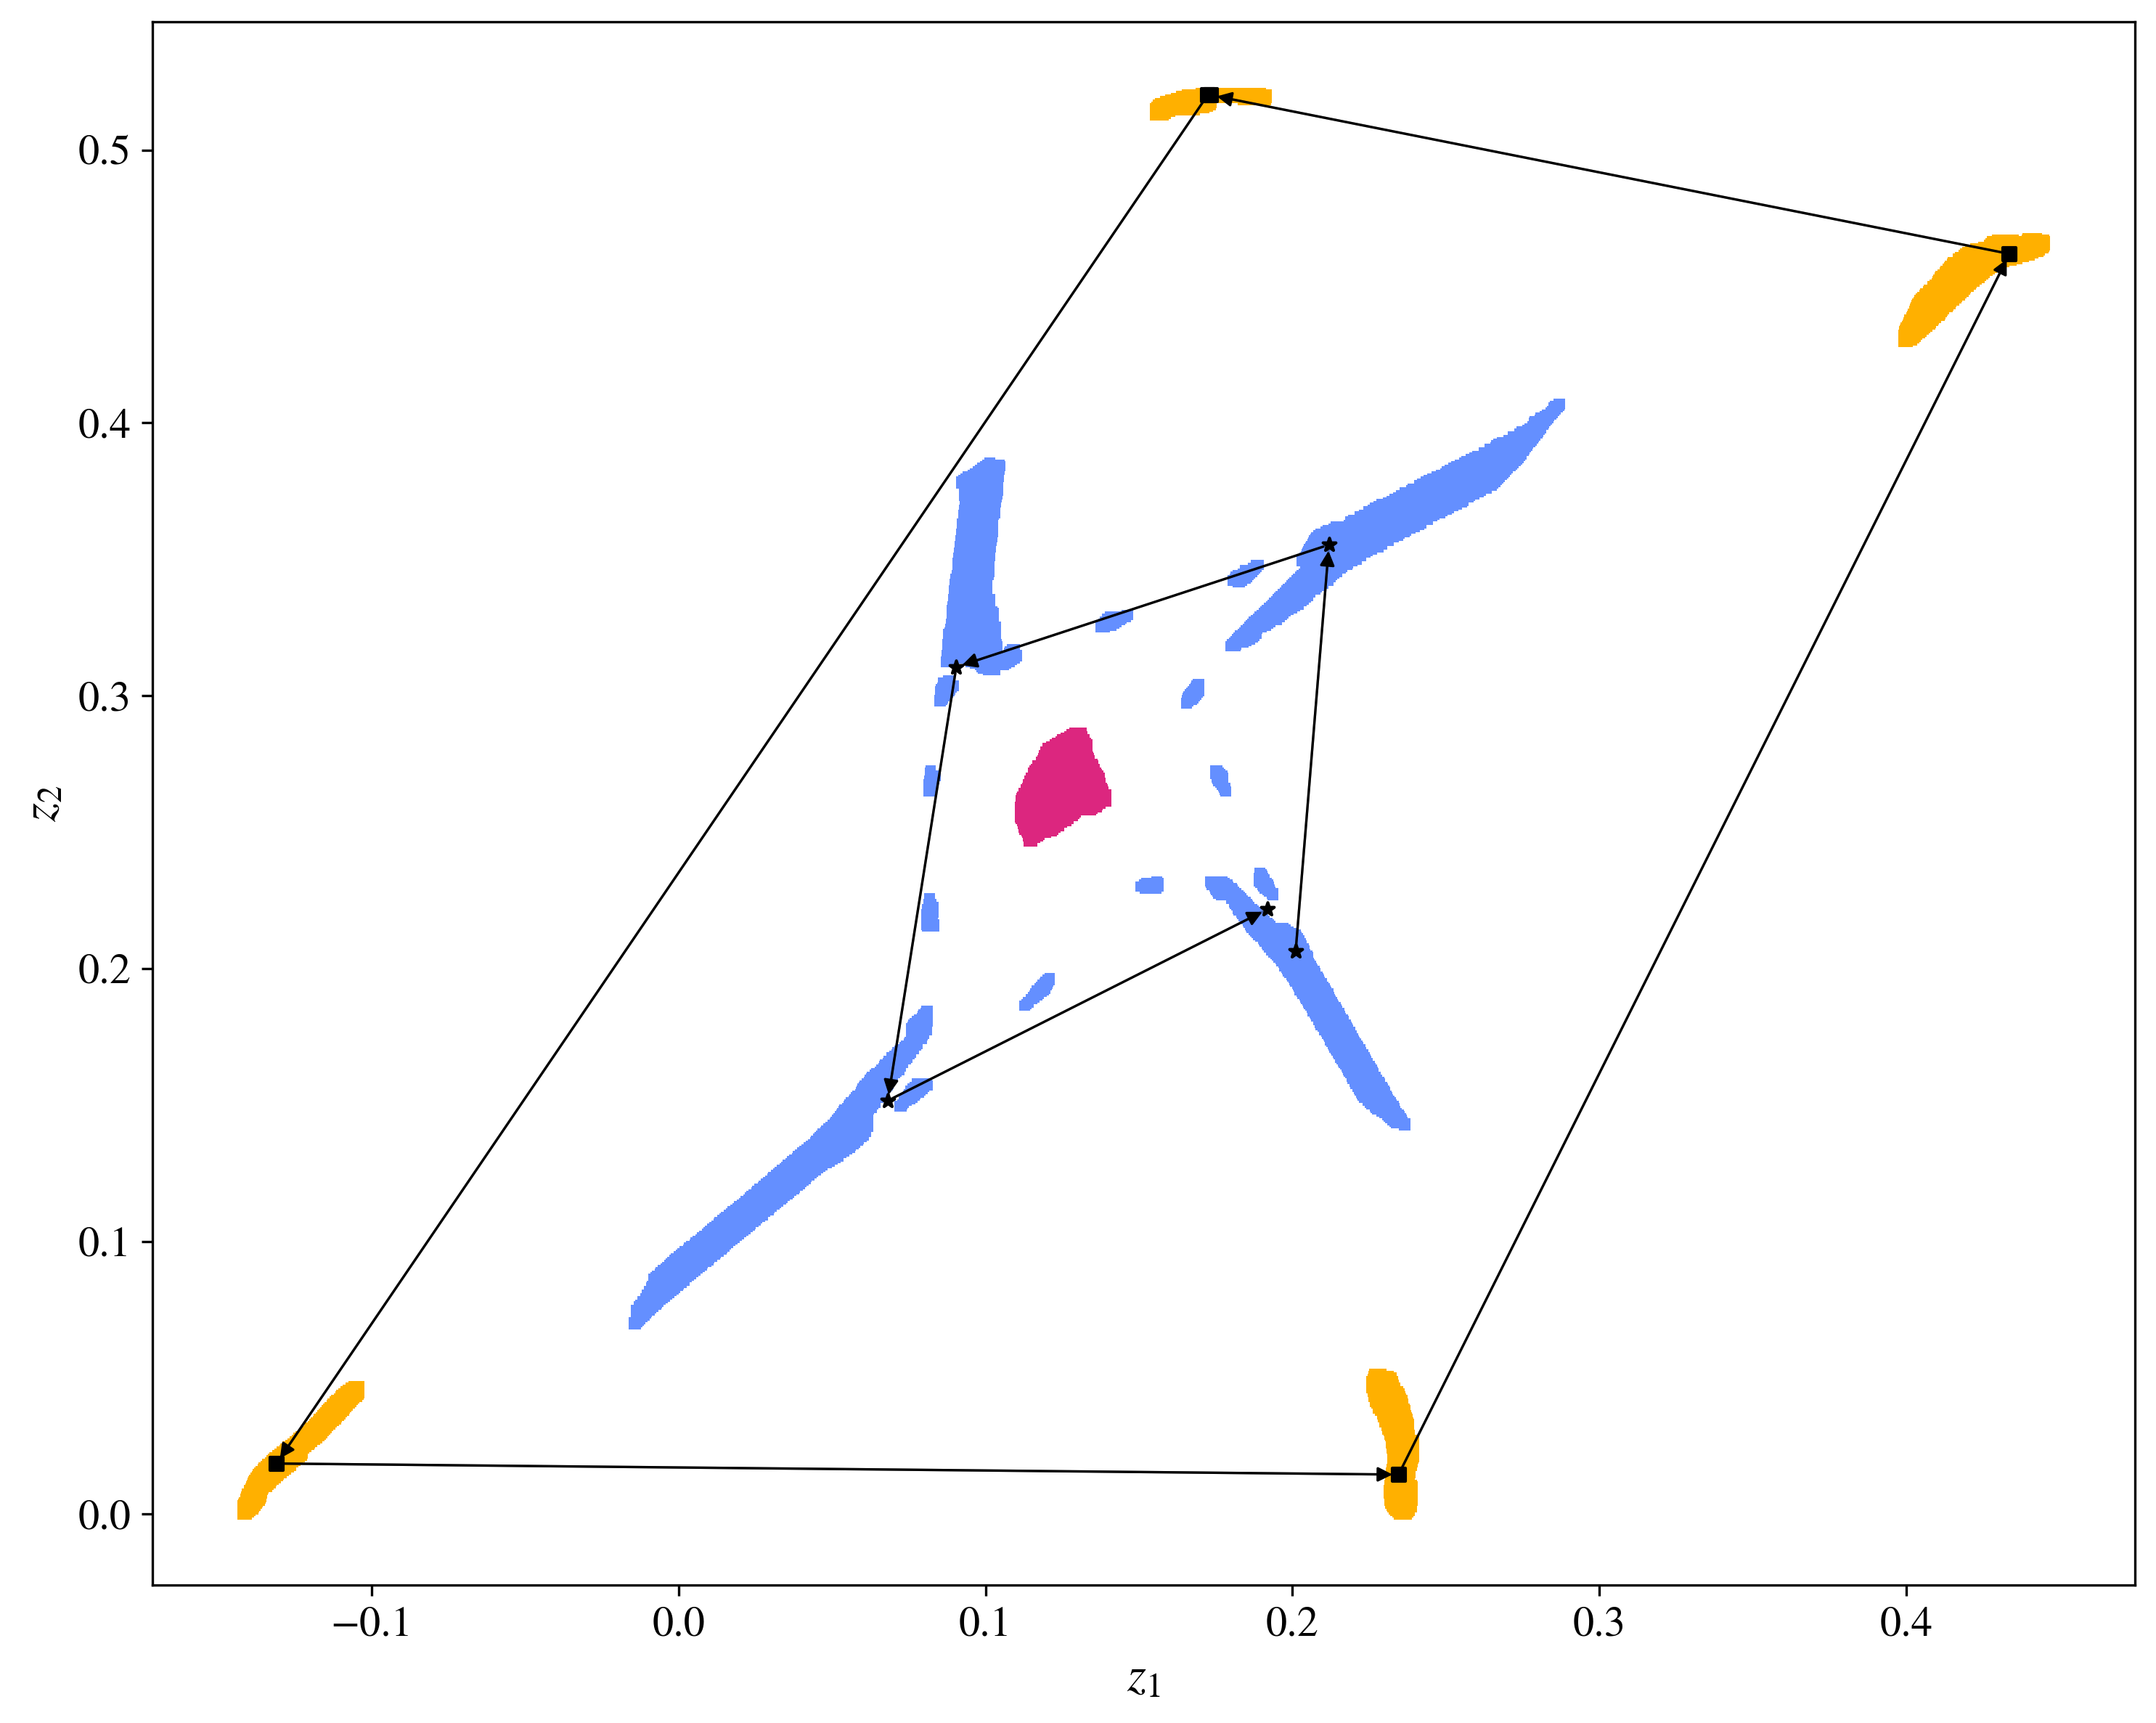

In [4]:
from latentdynamics.viz import plot_latent_trajectory
from latentdynamics.cli.render import LESLIE3D_PERIODIC_PTS

morse_sets = np.loadtxt(seed_dir_sp / 'MG' / 'morse_sets', delimiter=',', ndmin=2)
encode = lambda pts: encode_batch(model_sp, scaler_sp, pts)
advance = lambda z: advance_latent(model_sp, z)

traj_png = RENDER_ROOT / 'leslie3d_spurious' / 'latent_trajectory.png'
plot_latent_trajectory(
    morse_set_data=morse_sets,
    periodic_pts=LESLIE3D_PERIODIC_PTS,
    encode=encode,
    advance_latent=advance,
    save_path=traj_png,
    trajectory_steps=4,
)
show(traj_png, width=720)

## Success regime

seed_dir: /Users/bdoprad/Work/Projects/latent-dynamics/code/output/leslie3d_success/seed_0


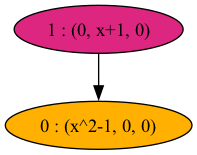

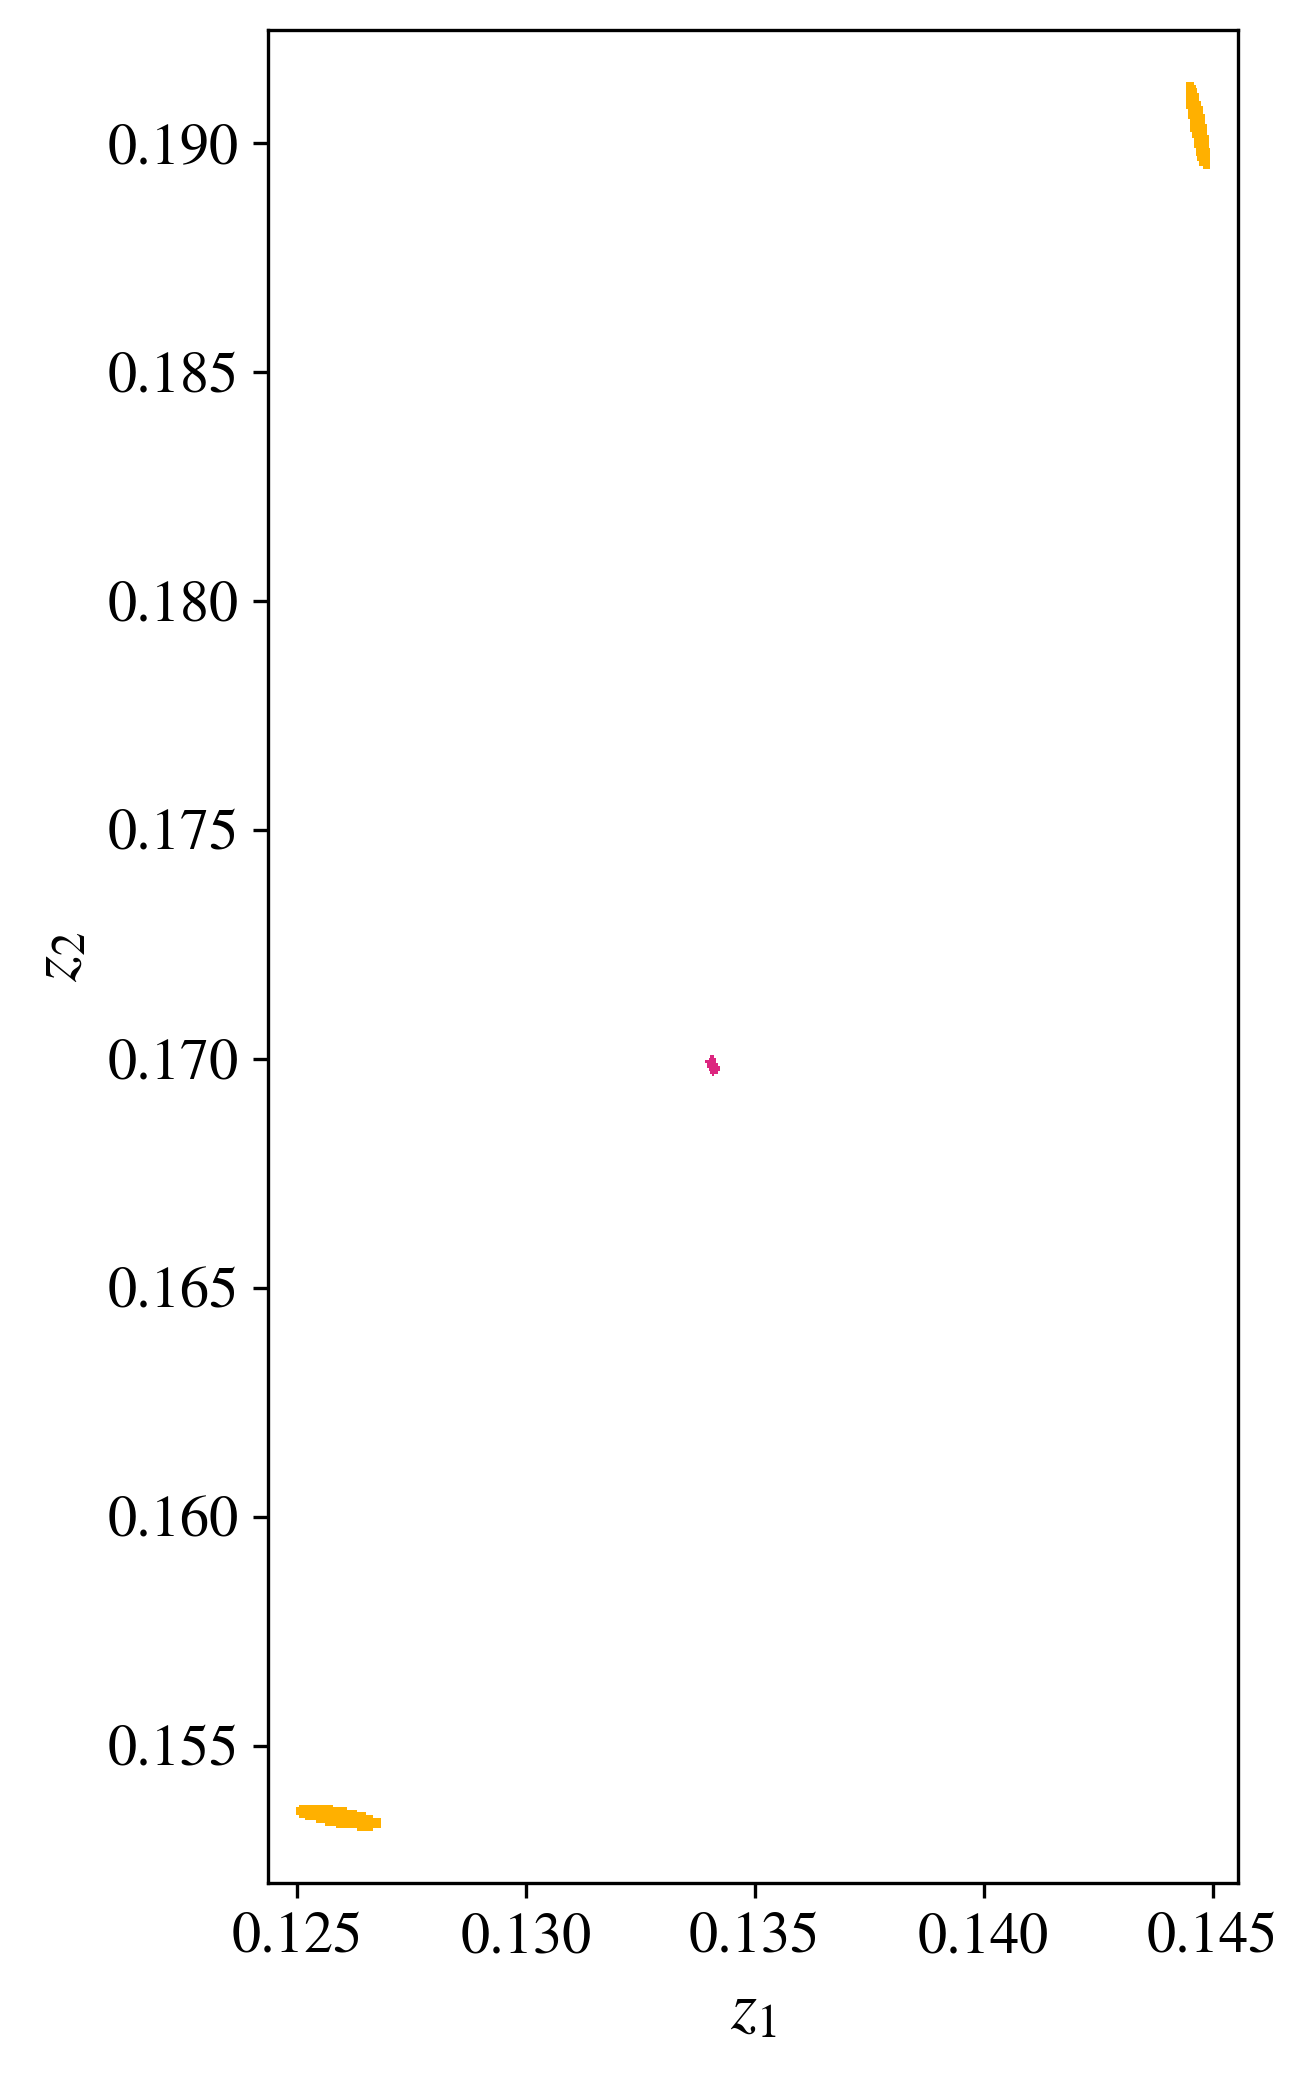

-- metrics.json --
{
  "target_label": 0,
  "tau_bar": 4.547834396362305e-05,
  "n_semiconjugacy_samples": 0,
  "error": "no sampled points encoded into target Morse set"
}


In [5]:
cfg_ok = load_config(REPO_ROOT / 'configs' / 'leslie3d_success.yaml')
SEED_OK = cfg_ok.seeds[0]
seed_dir_ok, model_ok, arch_ok, scaler_ok = load_replay(cfg_ok, SEED_OK)
print('seed_dir:', seed_dir_ok)

lower, upper = _bounds_from_log(seed_dir_ok / 'mg_params_log.txt')
render_dir = RENDER_ROOT / 'leslie3d_success'
figs = render_morse_from_files(seed_dir_ok / 'MG', bounds_lower=lower, bounds_upper=upper, out_dir=render_dir)
show(figs.morse_graph_png)
for p in figs.morse_sets_paths:
    if p.suffix == '.png':
        show(p, width=720)

metrics = json.loads((seed_dir_ok / 'metrics.json').read_text() or '{}')
print('-- metrics.json --')
print(json.dumps(metrics, indent=2) if metrics else '(empty)')